In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from dataset import Dog_Set
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import ConcatDataset
import numpy as np
from model import RoflNET
from dataset import Dog_Set
import utils
dataset_path ="Images"


BATCH_SIZE=8
NUM_WORKERS=2
WEIGHT_DECAY=(1e-4)
LR=(1e-3)/3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
'''
Аугментации для обучения и для теста resize 224 для encodera resnet 18
'''
train_transform = A.Compose([
    A.RandomResizedCrop(size=(224,224),scale=(0.7,1.0)),
    A.HorizontalFlip(p=0.3),
    A.Rotate(limit=20, p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.HueSaturationValue(p=0.2),
    A.GaussNoise(p=0.1),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])







'''загрузка датасета'''
dataset_train=Dog_Set(dataset_path,train_transform)
dataset_val=Dog_Set(dataset_path,val_transform)
val_size=int(0.15*len(dataset_train))
train_size=len(dataset_train)-val_size

train_ds, val_indices = random_split(dataset_train, [train_size, val_size])
val_ds = torch.utils.data.Subset(dataset_val, val_indices.indices)

train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)





In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
'''
простая обратная связь сложение выхода с входом 
'''
def con(x, z):
    return x+z
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.02,num_think=3,connection=con).to(DEVICE)
#Тут было до layer3    
NUM_EPOCH=50
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
)
loss_fn = torch.nn.CrossEntropyLoss()
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    if epoch % 5==0 and epoch > 25:
        utils.save_epoch_checkpoint(model, optimizer, epoch, "data1")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")

cuda


Epoch 0: train=4.2608 val=3.5835 val_acc=0.1213


Epoch 1: train=3.4887 val=2.9268 val_acc=0.2380


Epoch 2: train=3.0295 val=2.5482 val_acc=0.3155


Epoch 3: train=2.6950 val=2.2784 val_acc=0.3661


...

Epoch 41: train=0.7588 val=1.5907 val_acc=0.6203


Epoch 42: train=0.7395 val=1.5127 val_acc=0.6320


Epoch 43: train=0.7338 val=1.5304 val_acc=0.6407


Epoch 44: train=0.7038 val=1.5978 val_acc=0.6239


KeyboardInterrupt: 

In [ ]:
def con(x, z):
    return x-z
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.02,num_think=3,connection=con).to(DEVICE)
    
NUM_EPOCH=40
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
)
loss_fn = torch.nn.CrossEntropyLoss()


for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    '''if epoch % 5==0 and epoch > 10:
        utils.save_epoch_checkpoint(model, optimizer, epoch, "data1")'''
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")

cuda


Epoch 0: train=2.9182 val=2.0858 val_acc=0.4306


Epoch 1: train=2.1249 val=1.8705 val_acc=0.4844


Epoch 2: train=1.8481 val=1.6634 val_acc=0.5460


Epoch 3: train=1.6565 val=1.7108 val_acc=0.5347


...

Epoch 10: train=0.9970 val=1.8170 val_acc=0.5901


Epoch 11: train=0.9460 val=1.6615 val_acc=0.6242


Epoch 12: train=0.9034 val=1.7613 val_acc=0.6086


Epoch 13: train=0.8323 val=1.6426 val_acc=0.6174


 17%|█▋        | 367/2186 [00:36<02:28, 12.29it/s, loss=1.78]  

In [4]:
def con(x, z):
    return x
    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=1,connection=None).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=40
optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=WEIGHT_DECAY
)
loss_fn = torch.nn.CrossEntropyLoss()
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    '''if epoch % 5==0 and epoch > 10:
        utils.save_epoch_checkpoint(model, optimizer, epoch, "data1")'''
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")

cuda


Epoch 0: train=3.8595 val=2.5856 val_acc=0.2610


Epoch 1: train=3.0350 val=2.2733 val_acc=0.3398


Epoch 2: train=2.7587 val=2.0353 val_acc=0.4014


Epoch 3: train=2.5570 val=1.8840 val_acc=0.4407


...

Epoch 35: train=1.8393 val=1.3797 val_acc=0.6158


Epoch 36: train=1.8499 val=1.4293 val_acc=0.5970


Epoch 37: train=1.8359 val=1.4012 val_acc=0.6038


Epoch 38: train=1.8390 val=1.3654 val_acc=0.6122


Epoch 39: train=1.8274 val=1.3542 val_acc=0.6109


In [8]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR/2,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 :
        utils.save_epoch_checkpoint(model, optimizer, epoch+90, "data2")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 0: train=1.5716 val=1.2543 val_acc=0.6456


Epoch 1: train=1.5626 val=1.2725 val_acc=0.6488


Epoch 2: train=1.5639 val=1.2211 val_acc=0.6589


Epoch 3: train=1.5390 val=1.2692 val_acc=0.6482


Epoch 4: train=1.5499 val=1.2989 val_acc=0.6485


...

Epoch 30: train=1.4912 val=1.2380 val_acc=0.6634


Epoch 31: train=1.4811 val=1.2406 val_acc=0.6589


Epoch 32: train=1.4815 val=1.2313 val_acc=0.6582


Epoch 33: train=1.4922 val=1.2327 val_acc=0.6602


KeyboardInterrupt: 

In [9]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR/2,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 :
        utils.save_epoch_checkpoint(model, optimizer, epoch+90, "data2")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")

C:\Users\uraa-\mien_project\FatPhoto\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
                                                               

Epoch 0: train=1.5604 val=1.2872 val_acc=0.6453


Epoch 1: train=1.5751 val=1.2631 val_acc=0.6501


Epoch 2: train=1.5790 val=1.3030 val_acc=0.6469


Epoch 3: train=1.5711 val=1.3377 val_acc=0.6391


...

Epoch 35: train=1.3791 val=1.2895 val_acc=0.6553


Epoch 36: train=1.3990 val=1.2198 val_acc=0.6696


Epoch 37: train=1.4031 val=1.2346 val_acc=0.6657


Epoch 38: train=1.3957 val=1.2472 val_acc=0.6647


Epoch 39: train=1.4012 val=1.2321 val_acc=0.6712


In [3]:
loss_fn = torch.nn.CrossEntropyLoss()
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(f"runs/rec_plus")

''' До этого пристрелка была тут уже нормалньая проверка функция обратной связи '''

def con(x, z):
    return x+z
    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=con).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec+_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()



from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(f"runs/rec_sigm")

'''sigmoid связб'''

def con(x, z):
    return z+torch.sigmoid(x)*x
    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=con).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_sigm_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()

writer = SummaryWriter(f"runs/rec_torch")
'''tanh связь'''
def con(x, z):
    return z+torch.tanh(x)
    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=con).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_tan_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()




cuda


C:\Users\uraa-\mien_project\FatPhoto\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
                                                               

Epoch 0: train=4.6875 val=2.3537 val_acc=0.5762


Epoch 1: train=2.8998 val=2.0150 val_acc=0.6329


Epoch 2: train=2.6969 val=1.9276 val_acc=0.6530


...

Epoch 116: train=1.1793 val=0.8522 val_acc=0.7490


Epoch 117: train=1.1710 val=0.8453 val_acc=0.7458


Epoch 118: train=1.1770 val=0.8629 val_acc=0.7471


Epoch 119: train=1.1706 val=0.8317 val_acc=0.7536


NameError: name 'nn' is not defined

In [4]:

'''полиномиальная связь полином 2 го порядка'''
class PolyConnection(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = torch.nn.Parameter(torch.tensor(0.05))
        self.beta = torch.nn.Parameter(torch.tensor(0.1))
        self.gamma=torch.nn.Parameter(torch.tensor(0.05))

    def forward(self, z, x):
        poly = z + self.beta * z**2+self.gamma*z**3
        poly = poly / (poly.abs().mean(dim=(1,2,3), keepdim=True) + 1e-6)
        return x + self.alpha * poly *z 

writer = SummaryWriter(f"runs/polynom_con")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=PolyConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_Polyconnection_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()


cuda


Epoch 0: train=6.6557 val=2.3988 val_acc=0.5353


Epoch 1: train=2.1719 val=1.3477 val_acc=0.6193


Epoch 2: train=2.0118 val=1.4555 val_acc=0.5850


Epoch 3: train=1.8683 val=1.3383 val_acc=0.6433


...

Epoch 115: train=1.0986 val=0.9272 val_acc=0.7633


Epoch 116: train=1.1041 val=0.9566 val_acc=0.7549


Epoch 117: train=1.1137 val=0.9402 val_acc=0.7526


Epoch 118: train=1.1023 val=0.9476 val_acc=0.7484


Epoch 119: train=1.0998 val=0.9392 val_acc=0.7474


In [5]:
''' без обратной связи'''
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(f"runs/just 3 think no conn")
loss_fn = torch.nn.CrossEntropyLoss()
    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=None).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_No_con_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()


cuda


Epoch 0: train=2.8739 val=1.2552 val_acc=0.6232


Epoch 1: train=1.8175 val=1.0995 val_acc=0.6657


Epoch 2: train=1.6585 val=1.0231 val_acc=0.6920


Epoch 3: train=1.5486 val=1.0303 val_acc=0.6903


...

Epoch 115: train=0.9319 val=1.0663 val_acc=0.7312


Epoch 116: train=0.9389 val=1.0482 val_acc=0.7338


Epoch 117: train=0.9331 val=1.0338 val_acc=0.7351


Epoch 118: train=0.9371 val=1.0140 val_acc=0.7361


Epoch 119: train=0.9338 val=1.0734 val_acc=0.7260


In [6]:
'''
полиномиальная обратная связь, полином 4го порядка
'''

class PolyConnection4(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = torch.nn.Parameter(torch.tensor(0.05))
        self.beta = torch.nn.Parameter(torch.tensor(0.1))
        self.gamma=torch.nn.Parameter(torch.tensor(0.05))
        self.dzeta = torch.nn.Parameter(torch.tensor(0.05))
        self.kappa = torch.nn.Parameter(torch.tensor(0.05))

    def forward(self, z, x):
        poly = z + self.beta * z**2+self.gamma*z**3+self.dzeta*z**4+self.kappa*z**5
        poly = poly / (poly.abs().mean(dim=(1,2,3), keepdim=True) + 1e-6)
        return x + self.alpha * poly *z 

writer = SummaryWriter(f"runs/polynom_con4")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=PolyConnection4()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_Polyconnection4_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()





cuda


Epoch 0: train=404.8348 val=1.9937 val_acc=0.4546


Epoch 1: train=2.3833 val=1.6148 val_acc=0.5451


Epoch 2: train=2.0759 val=1.3365 val_acc=0.6018


Epoch 3: train=2.0298 val=1.3012 val_acc=0.6294


...

Epoch 116: train=1.1098 val=0.9099 val_acc=0.7468


Epoch 117: train=1.0970 val=0.9011 val_acc=0.7474


Epoch 118: train=1.1093 val=0.8466 val_acc=0.7678


Epoch 119: train=1.1064 val=0.8554 val_acc=0.7610


NameError: name 'nn' is not defined

In [7]:
import torch.nn as nn


'''разложение по случайным обучаемым модам поулчилось плохо'''
class FourierConnection(nn.Module):
    def __init__(self, modes=15):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.05))
        self.a = nn.Parameter(torch.randn(modes) * 0.1)
        self.b = nn.Parameter(torch.randn(modes) * 0.1)
        self.modes = modes
    def forward(self, z, x):
        f = 0
        for k in range(self.modes):
            k1 = k + 1
            f = f + self.a[k] * torch.sin(k1 * z) + self.b[k] * torch.cos(k1 * z)
        f = f / (f.abs().mean(dim=(1,2,3), keepdim=True) + 1e-6)
        
        return x + self.alpha * f * z

writer = SummaryWriter(f"runs/fourie")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=FourierConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_FourierConnection_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()







cuda


Epoch 0: train=492.2200 val=830.9477 val_acc=0.0078


Epoch 1: train=964.1167 val=1057.3179 val_acc=0.0081


Epoch 2: train=996.0858 val=1045.6325 val_acc=0.0101


Epoch 3: train=1002.4774 val=1027.1630 val_acc=0.0078


...

Epoch 79: train=1153.2485 val=1180.9697 val_acc=0.0071


Epoch 80: train=1149.0409 val=1229.3274 val_acc=0.0065


Epoch 81: train=1150.7250 val=1185.9959 val_acc=0.0113


Epoch 82: train=1160.1346 val=1207.6481 val_acc=0.0058


KeyboardInterrupt: 

In [2]:
from torch.utils.tensorboard import SummaryWriter
import torch.nn as nn
loss_fn = torch.nn.CrossEntropyLoss()
'''
соединение с ошибкой возвращает на вход разницу между входом и предсказанием с обучаемым весом
'''
class Error_con(nn.Module):
    def __init__(self, modes=15):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.05))
    def forward(self, z, x):
        return x +self.alpha*(z-x)

writer = SummaryWriter(f"runs/Error_con")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=3,percent=0.02,num_think=3,connection=Error_con()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    if epoch % 5==0 and epoch>50 :
        utils.save_epoch_checkpoint(model, optimizer, epoch, "datarec_Error_con_think3")
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()




cuda


C:\Users\uraa-\mien_project\FatPhoto\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
                                                               

Epoch 0: train=2.7302 val=1.2499 val_acc=0.6258


Epoch 1: train=1.7943 val=1.1153 val_acc=0.6689


Epoch 2: train=1.6108 val=1.0746 val_acc=0.6890


...

Epoch 115: train=0.9223 val=1.0079 val_acc=0.7500


Epoch 116: train=0.9293 val=0.9984 val_acc=0.7523


Epoch 117: train=0.9325 val=1.0158 val_acc=0.7458


Epoch 118: train=0.9167 val=1.0303 val_acc=0.7422


Epoch 119: train=0.9505 val=0.9839 val_acc=0.7523


In [ ]:





loss_fn = torch.nn.CrossEntropyLoss()
from torch.utils.tensorboard import SummaryWriter

print(DEVICE)
''' полиномы разная глубина и итерации'''

class PolyConnection(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = torch.nn.Parameter(torch.tensor(0.05))
        self.beta = torch.nn.Parameter(torch.tensor(0.1))
        self.gamma=torch.nn.Parameter(torch.tensor(0.05))

    def forward(self, z, x):
        poly = z + self.beta * z**2+self.gamma*z**3
        poly = poly / (poly.abs().mean(dim=(1,2,3), keepdim=True) + 1e-6)
        return x + self.alpha * poly *z 
        
writer = SummaryWriter(f"runs/rec_poly2_4_3")    
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.015,num_think=3,connection=PolyConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()





writer = SummaryWriter(f"runs/rec_poly2_5_3")    
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=5,percent=0.015,num_think=3,connection=PolyConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()


writer = SummaryWriter(f"runs/rec_poly2_4_4")    
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.01,num_think=4,connection=PolyConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()

LR=1e-4

writer = SummaryWriter(f"runs/rec_poly2_5_4")    
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=5,percent=0.01,num_think=4,connection=PolyConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()


In [5]:

LR=1e-4

writer = SummaryWriter(f"runs/rec_poly2_5_4")    
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=5,percent=0.01,num_think=4,connection=PolyConnection()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=3,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()





class Error_con(torch.nn.Module):
    def __init__(self, modes=15):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.05))
    def forward(self, z, x):
        return x +self.alpha*(z-x)





Epoch 0: train=2045.3790 val=2.2288 val_acc=0.4186


Epoch 1: train=2.5639 val=1.6455 val_acc=0.5289


Epoch 2: train=2.2954 val=1.6463 val_acc=0.5778


Epoch 3: train=2.0161 val=1.3244 val_acc=0.6115


Epoch 4: train=1.9826 val=1.3229 val_acc=0.6628


...

Epoch 116: train=1.0075 val=1.1096 val_acc=0.7510


Epoch 117: train=0.9825 val=1.1546 val_acc=0.7536


Epoch 118: train=0.9885 val=1.2283 val_acc=0.7474


Epoch 119: train=0.9920 val=1.1460 val_acc=0.7442


NameError: name 'nn' is not defined

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import torch.nn as nn

loss_fn = torch.nn.CrossEntropyLoss()

class Error_con(torch.nn.Module):
    def __init__(self, modes=15):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.05))
    def forward(self, z, x):
        return x +self.alpha*(z-x)



writer = SummaryWriter(f"runs/Error_con_4_3")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.01,num_think=3,connection=Error_con()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=5,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()



writer = SummaryWriter(f"runs/Error_con_5_3")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=5,percent=0.01,num_think=3,connection=Error_con()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=5,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()




writer = SummaryWriter(f"runs/Error_con_4_4")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.01,num_think=4,connection=Error_con()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=5,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()



writer = SummaryWriter(f"runs/Error_con_4_2")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.01,num_think=2,connection=Error_con()).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=5,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()




'''No connection no think'''
writer = SummaryWriter(f"runs/3_additional_layers")

    
print(DEVICE)
model = RoflNET(out_channels=120,num_lay1=4,num_laythink=4,percent=0.01,num_think=1,connection=None).to(DEVICE)    
for param in model.encoder.parameters():
    param.requires_grad = False
model.encoder.eval()
NUM_EPOCH=120

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=5,
    verbose=True
)
for epoch in range(NUM_EPOCH):
    train_loss = utils.train_one_epoch(
        train_loader, model, optimizer, loss_fn, DEVICE
    )
    val_loss, val_acc = utils.validate(
        val_loader, model, loss_fn, DEVICE
    )
    scheduler.step(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f} val={val_loss:.4f} val_acc={val_acc:.4f}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
writer.close()




cuda


C:\Users\uraa-\mien_project\FatPhoto\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
                                                               

Epoch 0: train=2.7679 val=1.4547 val_acc=0.5775


Epoch 1: train=1.8262 val=1.1802 val_acc=0.6359


Epoch 2: train=1.6390 val=1.1128 val_acc=0.6625


...

Epoch 75: train=0.8537 val=1.2026 val_acc=0.7260


Epoch 76: train=0.8511 val=1.2180 val_acc=0.7156


Epoch 77: train=0.8596 val=1.2407 val_acc=0.7176


Epoch 78: train=0.8549 val=1.2685 val_acc=0.7137


 60%|██████    | 1314/2186 [00:36<00:18, 46.85it/s, loss=0.684] 

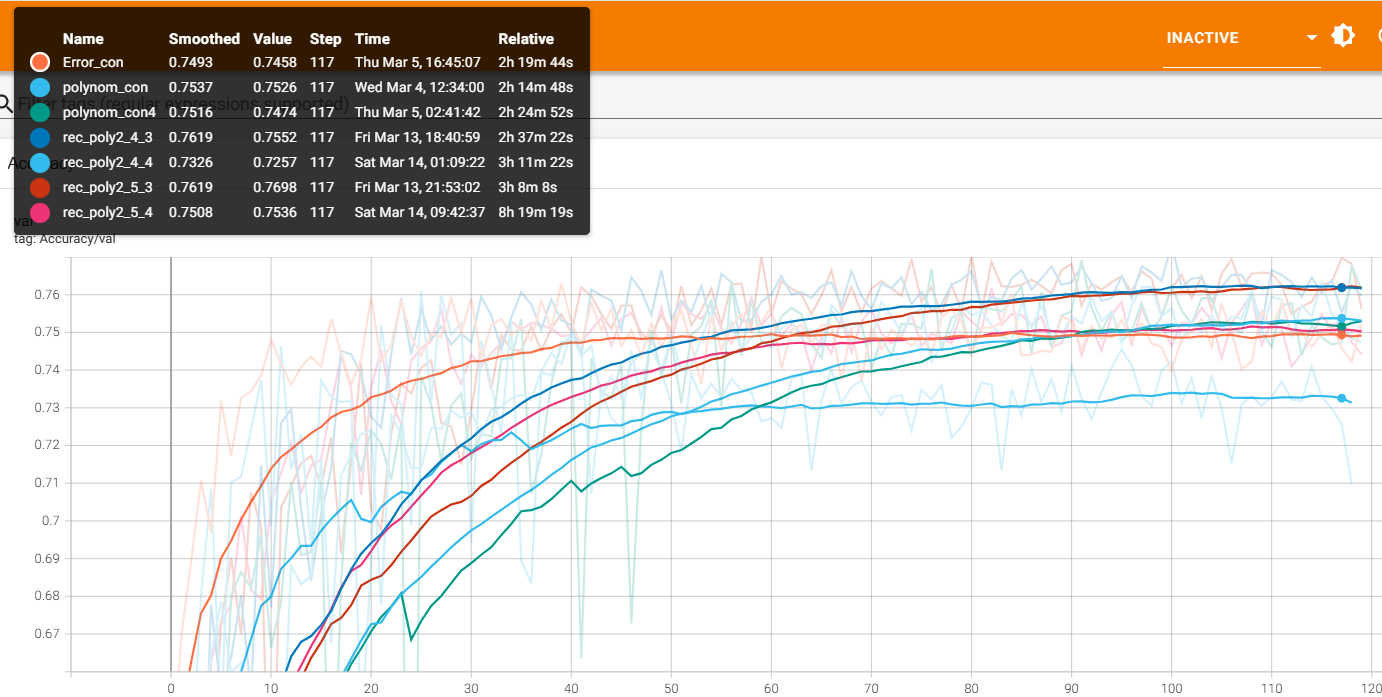
Основная задумка была рассмотреть рассмотреть следующую гипотезу,предположим что некотоаря часть классификации в таксаномии некоторых объектов происходит ближе к концу модели, возьмем предобученный энкодер в данной реализации resnet18(Imagenet),назовем thinklayer отдельную часть модели где мы будем при помощи итерационных предсказаний получать результат.В дальнейшем если это имеет смысл думаю стоит рассмотреть возможно разные части энкодера, посмотреть какое приращение даст часть классификации, возможно имеет смысл взять более слабый энкодер отдельно предобучить его по Imagenet и уже отдельно изучать зависимости от количества итераций и глубины thinklayer, вида обратной связи, как можно заметить по первому прогону вид обратной связи может дать отклонение в 0.02 val accuracy при обучении модели, что в ряде случаев может быть важным. так же стоит рассмотреть как изменяется качество предсказания если попробовать сравнить предсказания полученные на более ранних итерациях и более поздних.mm

В данный момент попробованные следующие обратные связи :

x- вход в блок Think f- отображение от входа к выходу блока  z- вход блок на следющей итерации. еще важный момент что x- берется всегда как вход в нулевой итерации x=x[0]-где это была бы какая то i-тая итерация,а не как в последующих итерациях это тоже стоит провертить, на предмет того что мы каждый раз уточняем результат, прекрутить какие то физичные вещи или методы.
Poly connection

$$z_{i}=x+\sum{A_i*f(z_{i-1})}$$
$$ A_i- обучаемые$$
Error connection
z_{i}=x+f(z_{i-1})
$$z_{i}=x+A*(f(z_{i-1}])-x)$$
$$A-Обучаемый$$

linear connection
$$z_{i}=x+f(z{i-1})$$

tanh connection
$$z_i=x+tanh(f(z_{i-1}))$$

sigmoid connection

$$z_i=x+sigmoid(f(z_{i-1}))$$


Работы еще много я постараюсь в течении недели на ночь может оставлять или что то подобно вычислять больше хочется все таки много чего проверить.



в случае получения статистически заметного прироста от такого thinklayer можно будет попробовать сравнить с текущими sota моделями и моделями сравнимого веса на imagenet 1к.

если есть желание посмотреть полностью данные об обучении то могу выслать tensorboard файлы,

Текущий план лучше всего показали себя обратная связь с ошибкой и полирномиальная, в дальнейшем исследовать именно их, исследовать разную глубину разное количество итераций сравнивать с отсутсвием обратной связи, и простой обратной связью x+z, 